# Phase 0: EDA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Basic Overview

In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing.csv")

# Basic info
print("Shape: ", df.shape)
print("Dtypes:\n",df.dtypes)
print(df.head())

# Quick stats
df.describe()


Shape:  (39523, 20)
Dtypes:
 year             int64
month            int64
day              int64
hour             int64
zone             int64
city            object
longitude      float64
latitude       float64
aqi              int64
co             float64
no             float64
no2            float64
o3             float64
so2            float64
pm2_5          float64
pm10           float64
nh3            float64
temperature    float64
dewpt          float64
date            object
dtype: object
   year  month  day  hour  zone     city  longitude  latitude  aqi       co  \
0  2020     11   25     1    46  Beijing   116.3913   39.9062    5  3952.03   
1  2020     11   25     2    46  Beijing   116.3913   39.9062    5  3417.97   
2  2020     11   25     3    46  Beijing   116.3913   39.9062    5  2429.96   
3  2020     11   25     4    46  Beijing   116.3913   39.9062    5   674.25   
4  2020     11   25     5    46  Beijing   116.3913   39.9062    5   554.09   

       no     no2     

,year,month,day,hour,zone,longitude,latitude,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,temperature,dewpt
count,39523.000000,39523.000000,39523.000000,39523.000000,39523.0,3.952300e+04,3.952300e+04,39523.0,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000,39523.000000
mean,2022.698075,6.333806,15.750854,11.499279,46.0,1.163913e+02,3.990620e+01,5.0,2345.814858,144.173501,91.063489,26.779820,133.952515,211.577522,261.376325,27.179975,12.702318,1.246396
std,1.357768,3.498325,8.787472,6.921730,0.0,6.937827e-11,2.211237e-11,0.0,2484.826084,182.739507,91.710294,69.083665,125.830116,227.032593,276.418809,34.674197,12.021043,14.531251
min,2020.000000,1.000000,1.000000,0.000000,46.0,1.163913e+02,3.990620e+01,5.0,108.100000,0.000000,-9999.000000,-9999.000000,1.320000,0.000000,-9999.000000,0.000000,-20.000000,-39.900000
25%,2022.000000,3.000000,8.000000,5.500000,46.0,1.163913e+02,3.990620e+01,5.0,667.570000,8.160000,52.090000,0.000000,49.110000,53.350000,73.885000,6.520000,1.700000,-10.700000
50%,2023.000000,6.000000,16.000000,11.000000,46.0,1.163913e+02,3.990620e+01,5.0,1388.550000,69.740000,83.630000,1.720000,93.460000,132.000000,165.680000,15.070000,13.600000,1.900000
75%,2024.000000,9.000000,23.000000,17.000000,46.0,1.163913e+02,3.990620e+01,5.0,3097.530000,216.360000,119.270000,38.980000,175.480000,289.450000,356.825000,33.440000,23.000000,13.900000
max,2025.000000,12.000000,31.000000,23.000000,46.0,1.163913e+02,3.990620e+01,5.0,18585.210000,1316.070000,537.400000,469.210000,1144.410000,1825.930000,2578.450000,324.250000,41.600000,27.800000


In [ ]:
df.isna().sum()

,0
year,0
month,0
day,0
hour,0
zone,0
city,0
longitude,0
latitude,0
aqi,0
co,0


### Missing Values Heatmap

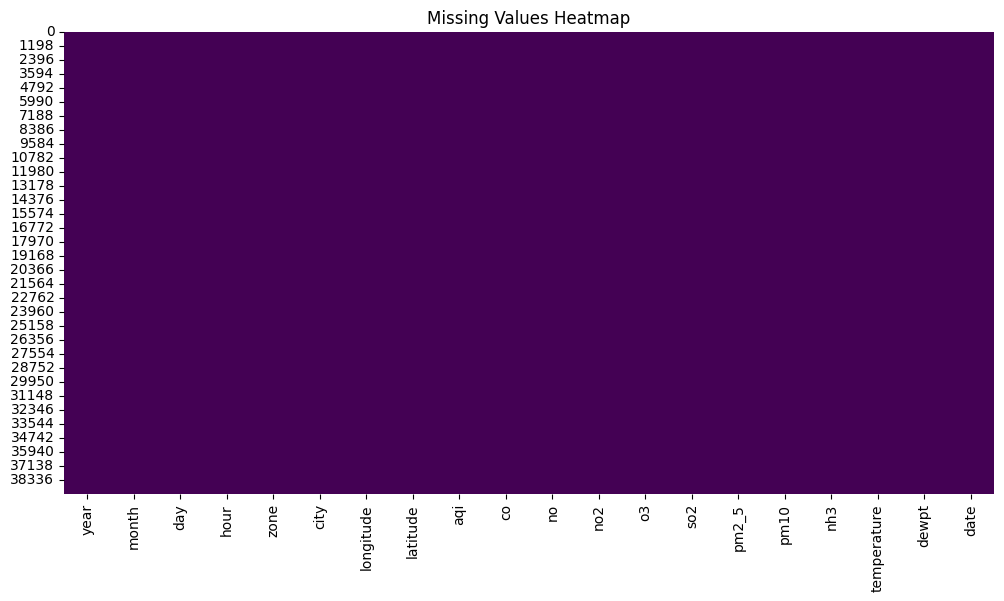

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


### Histograms of Key Variables

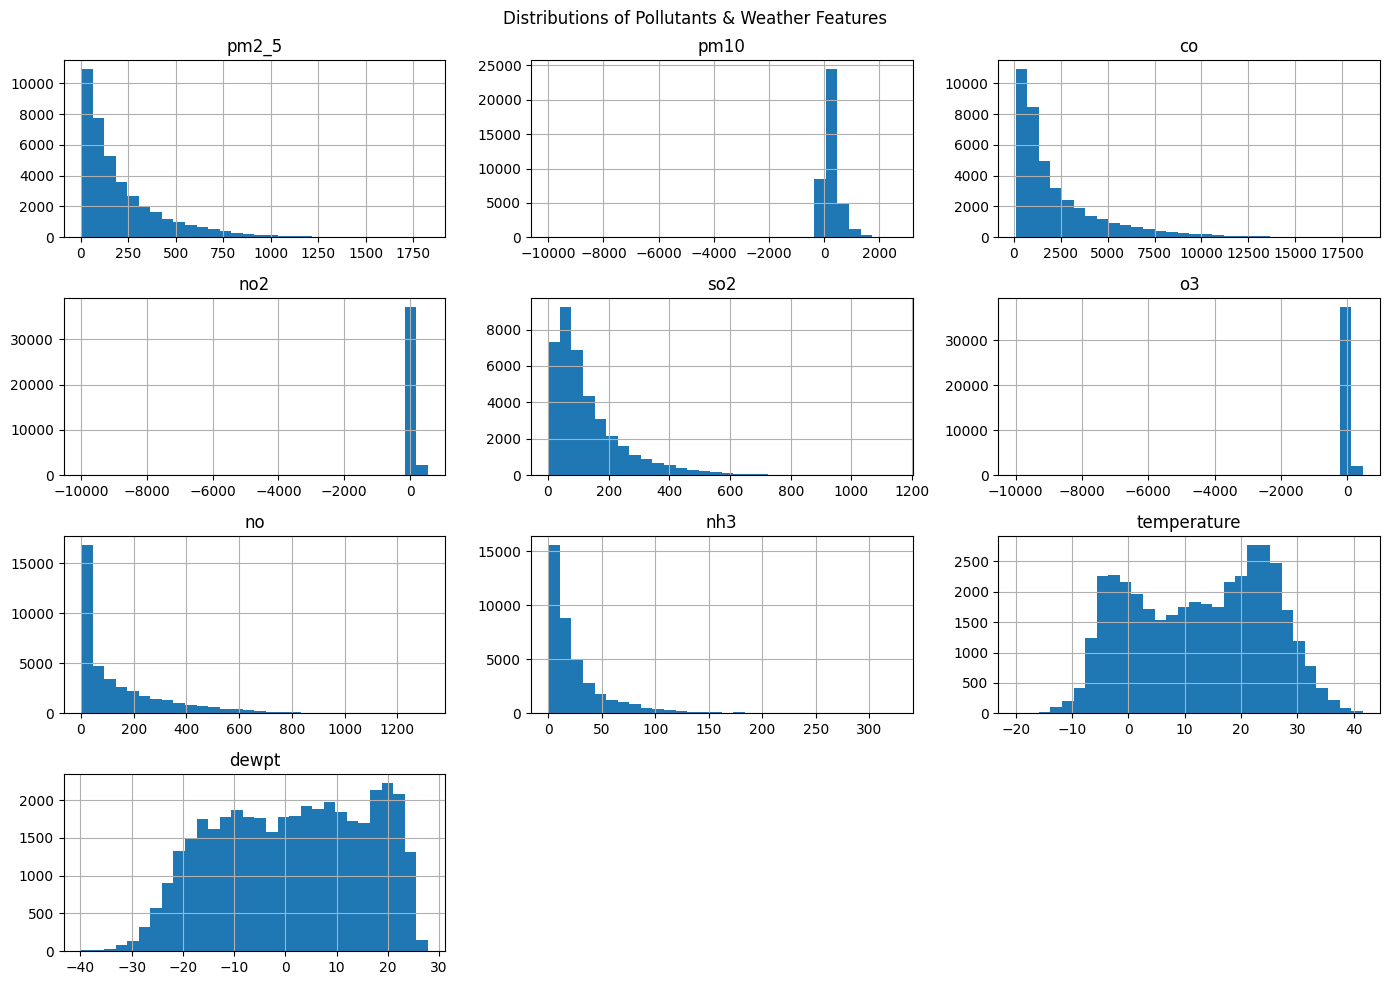

In [6]:
pollutants = ['pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3', 'no', 'nh3']
weather = ['temperature', 'dewpt']

df[pollutants + weather].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distributions of Pollutants & Weather Features")
plt.tight_layout()
plt.show()


### Time Series Plots

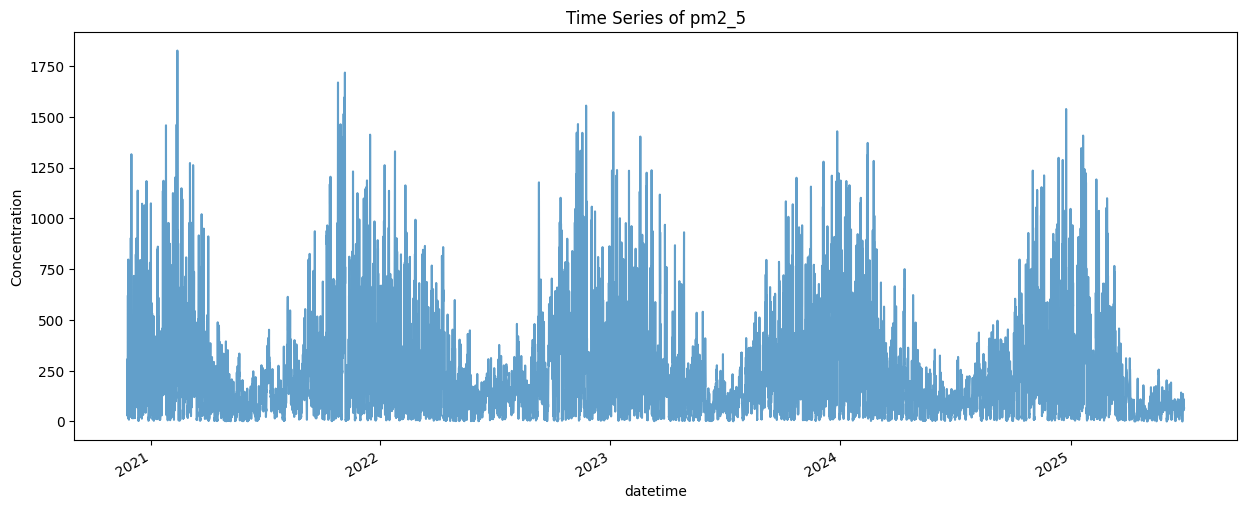

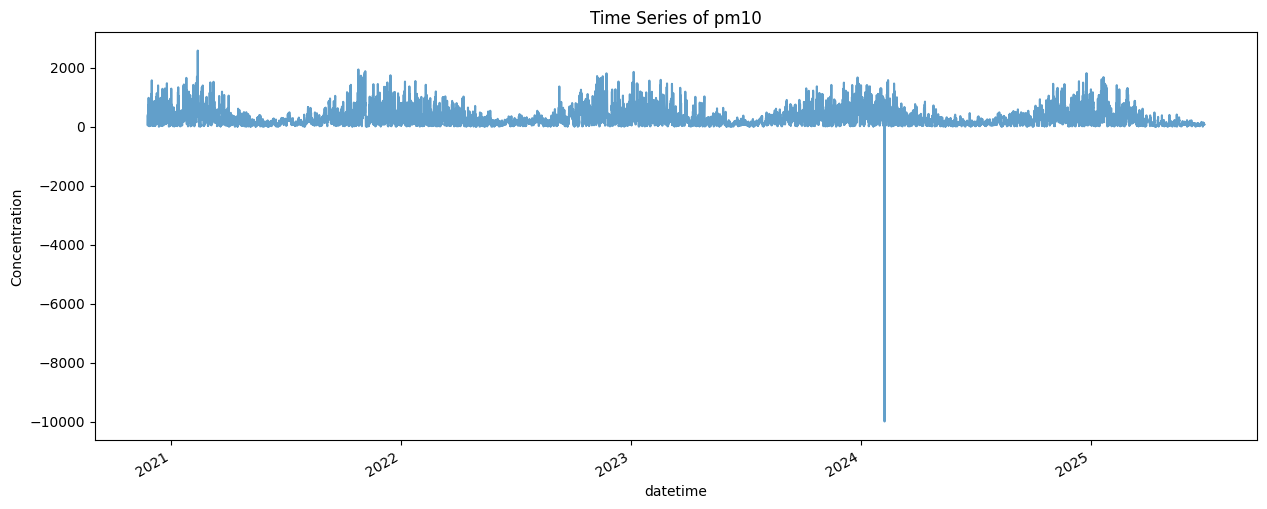

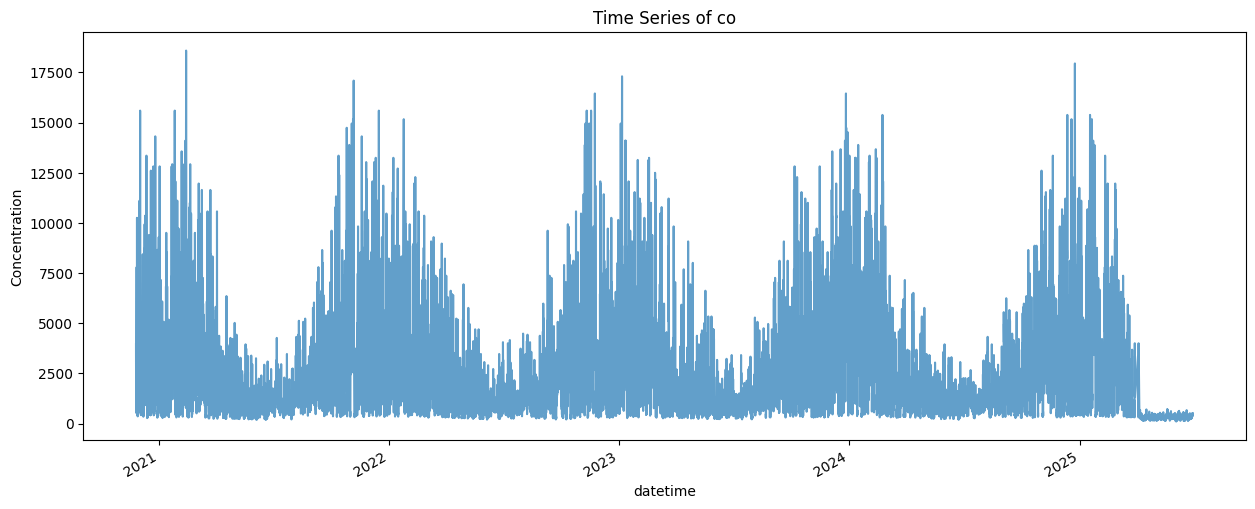

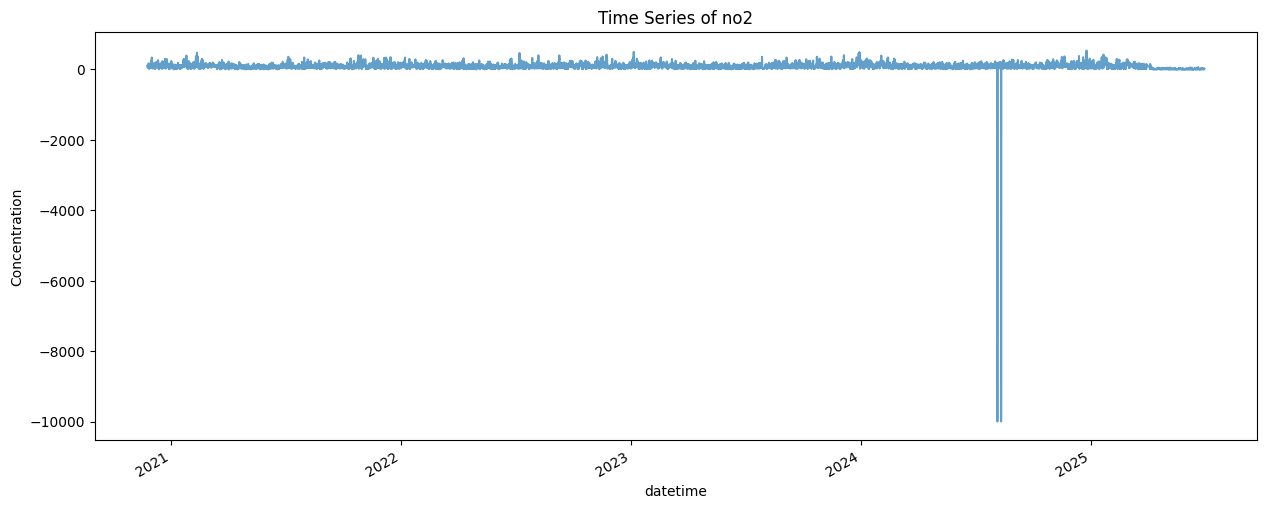

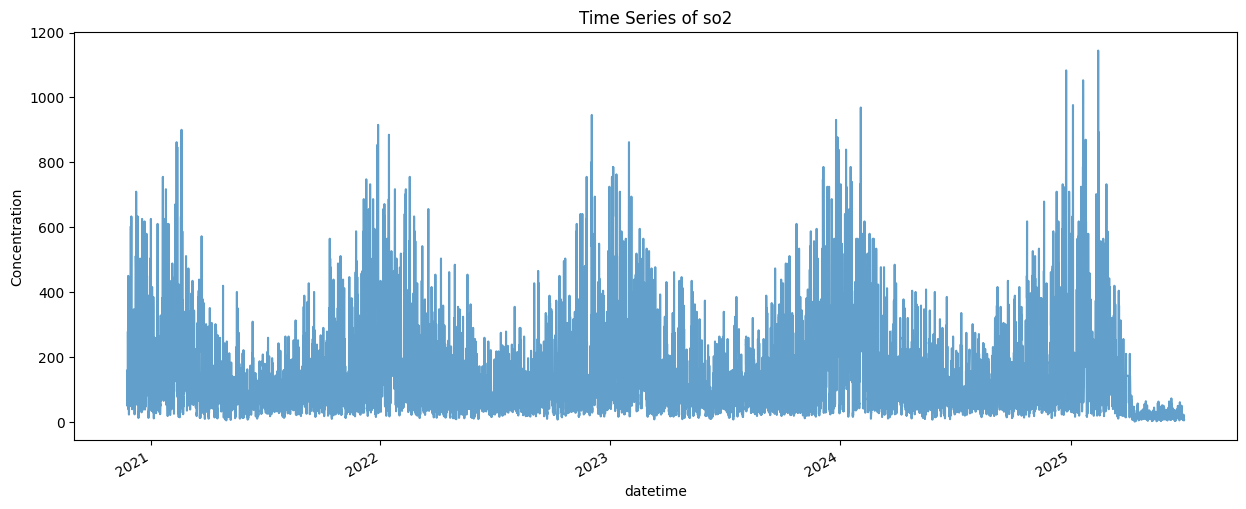

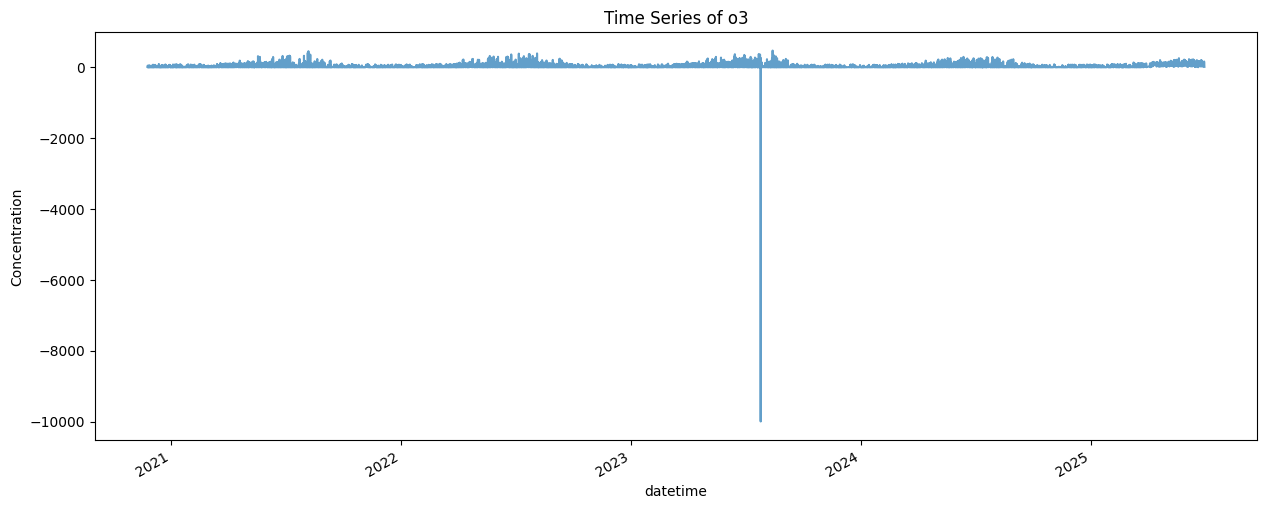

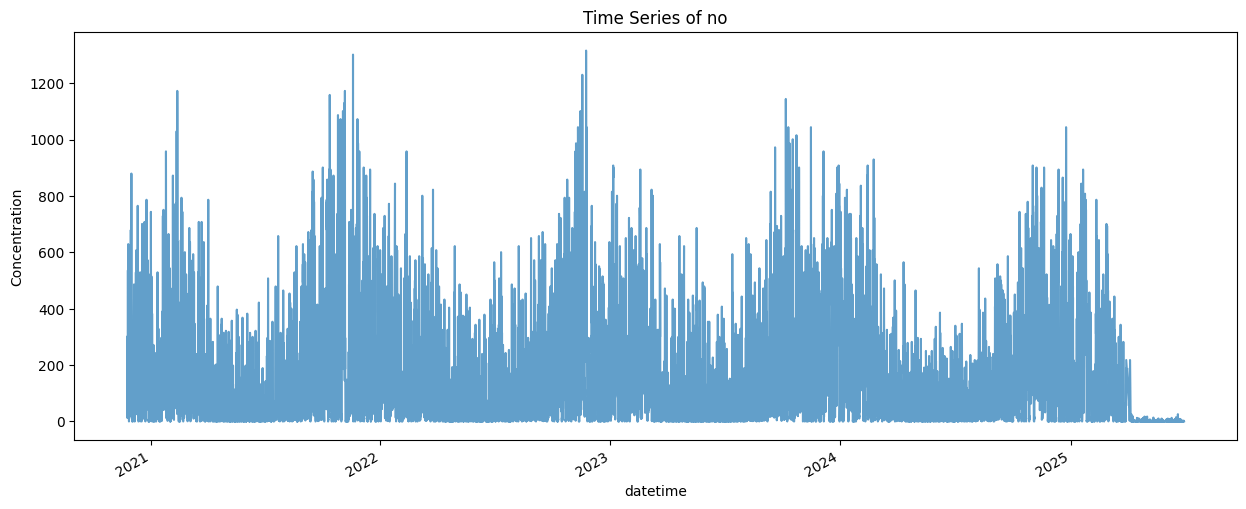

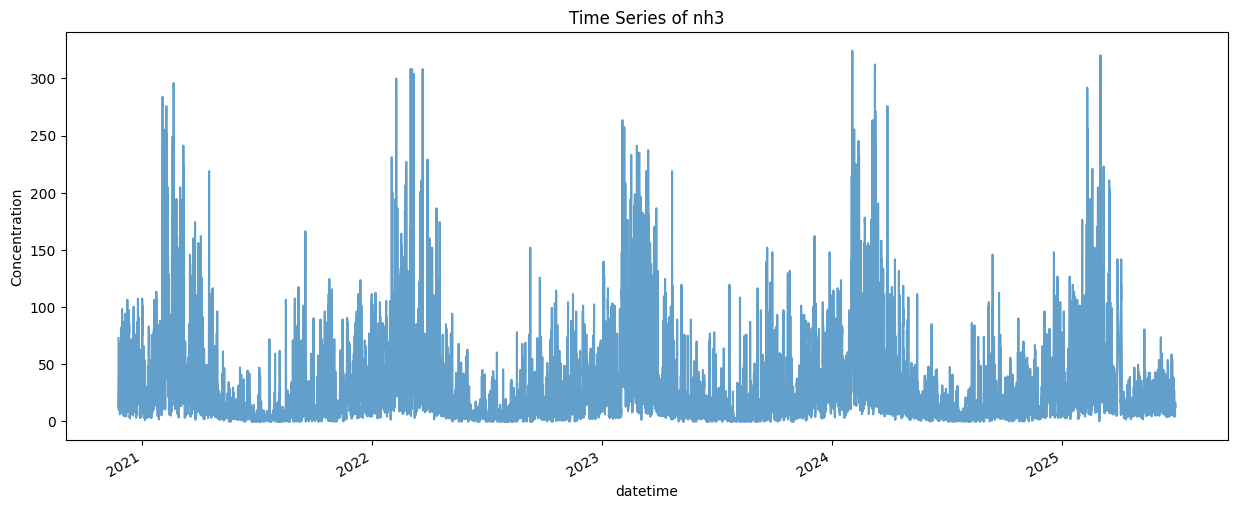

In [7]:
# Parse datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)

for pollutant in pollutants:
# Plot pollutants over time
    df[pollutant].plot(figsize=(15, 6), alpha=0.7)
    plt.title(f"Time Series of {pollutant}")
    plt.ylabel("Concentration")
    plt.show()


### Correlation Heatmap

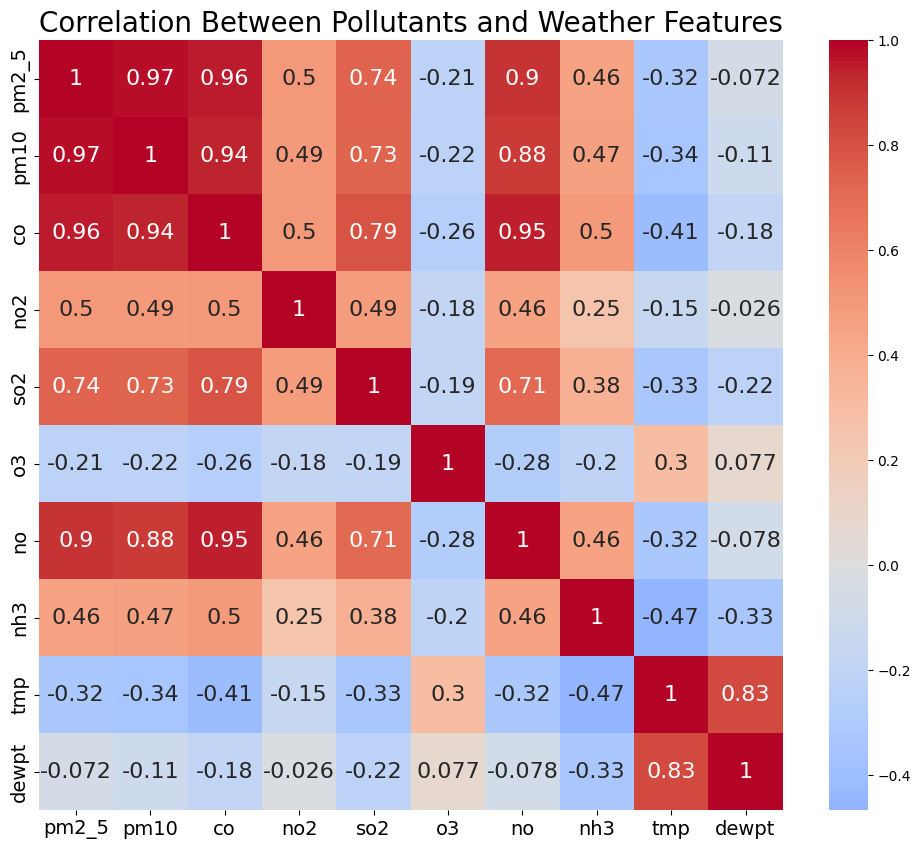

In [9]:
plt.figure(figsize=(12, 10))
corr = df[pollutants + weather].corr()

# rename columns and index only for plotting
corr = corr.rename(columns={"temperature": "tmp"}, index={"temperature": "tmp"})

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 16}
)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Correlation Between Pollutants and Weather Features", fontsize=20)
plt.show()


# Phase 1: Data Preparation

### Load Data & Parse Datetime

In [10]:
# Load CSV
df = pd.read_csv("/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing.csv")

# Combine year, month, day, hour into datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Set datetime as index
df.set_index('datetime', inplace=True)

# Drop any redundant columns if desired
df.drop(columns=['year', 'month', 'day', 'hour', 'zone', 'city', 'longitude', 'latitude', 'date', 'aqi'], inplace=True)

# Sort by datetime
df = df.sort_index()

df.tail()


,co,no,no2,o3,so2,pm2_5,pm10,nh3,temperature,dewpt
datetime,,,,,,,,,,
2025-06-29 15:00:00,474.83,0.00,17.00,43.27,6.21,62.06,69.47,13.76,23.0,21.9
2025-06-29 16:00:00,480.46,0.00,17.84,31.00,5.06,62.20,69.60,12.63,22.6,21.8
2025-06-29 17:00:00,489.43,0.01,18.80,22.09,4.75,62.34,69.32,12.17,22.5,21.6
2025-06-29 18:00:00,500.19,0.02,20.09,15.62,4.99,63.12,69.68,12.01,22.3,21.5
2025-06-29 19:00:00,510.52,0.06,22.01,10.96,6.04,64.31,70.41,16.37,22.2,21.5


### Data Splitting

In [15]:
# 90/10 split (time-based, no shuffle) — done FIRST, before any statistics are computed
n_total = len(df)
n_test  = int(n_total * 0.10)
n_train = n_total - n_test

df_train = df.iloc[:n_train].copy().reset_index()
df_test  = df.iloc[n_train:].copy().reset_index()

# Sanity check
print("Total rows:", n_total)
print("Train rows:", len(df_train))
print("Test  rows:", len(df_test))
print("Sum check: ", len(df_train) + len(df_test))

"""### Save Clean (Pre-Winsorization) Splits

These files are the primary input for Regime 1 and Regime 2.
Winsorization is NOT applied here — each regime script handles it
at the appropriate granularity:

  - Regime 1 (walk-forward): fits bounds from the expanding training
    window at every iteration, so each test-week forecast is clipped
    with bounds that only use data available at that point.

  - Regime 2 (frozen model): fits bounds once on df_train_initial and
    applies those same frozen bounds to every test-week slice.

This is the methodologically correct approach for a rolling evaluation:
no future data pollutes any preprocessing decision.
"""


Total rows: 39523
Train rows: 35571
Test  rows: 3952
Sum check:  39523


'### Save Clean (Pre-Winsorization) Splits\n\nThese files are the primary input for Regime 1 and Regime 2.\nWinsorization is NOT applied here — each regime script handles it\nat the appropriate granularity:\n\n  - Regime 1 (walk-forward): fits bounds from the expanding training\n    window at every iteration, so each test-week forecast is clipped\n    with bounds that only use data available at that point.\n\n  - Regime 2 (frozen model): fits bounds once on df_train_initial and\n    applies those same frozen bounds to every test-week slice.\n\nThis is the methodologically correct approach for a rolling evaluation:\nno future data pollutes any preprocessing decision.\n'

In [16]:
clean_train_path = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_train_clean.csv"
clean_test_path  = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_test_clean.csv"

df_train.to_csv(clean_train_path, index=False)
df_test.to_csv(clean_test_path,  index=False)

print(f"Saved (clean, unwinsorized): {clean_train_path}")
print(f"Saved (clean, unwinsorized): {clean_test_path}")

"""### Winsorization Bounds (Documentation / Reproducibility)

Compute and store the 1%–99% bounds from the training set only.
These are saved for:
  - Paper reproducibility (reviewers can verify the exact bounds used)
  - Regime 2, which freezes these bounds together with the model

NOTE: Regime 1 will RECOMPUTE bounds from its expanding training window
at each walk-forward iteration — it does NOT use this file for clipping.
"""

numeric_cols = df_train.select_dtypes(include="number").columns
lower_q, upper_q = 0.01, 0.99

wins_low  = df_train[numeric_cols].quantile(lower_q)
wins_high = df_train[numeric_cols].quantile(upper_q)

wins_bounds = pd.DataFrame({'low': wins_low, 'high': wins_high})
wins_bounds.to_csv("/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/winsorization_bounds.csv")

print(f"\nWinsorization bounds (from {len(df_train)} training rows) saved to "
      f"data/winsorization_bounds.csv")
print(wins_bounds)


Saved (clean, unwinsorized): /content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_train_clean.csv
Saved (clean, unwinsorized): /content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_test_clean.csv

Winsorization bounds (from 35571 training rows) saved to data/winsorization_bounds.csv
                 low       high
co           260.350  11642.460
no             0.000    786.780
no2           12.340    282.410
o3             0.000    220.300
so2           14.900    595.090
pm2_5          3.820   1043.432
pm10           6.604   1247.756
nh3            0.000    178.340
temperature   -9.400     35.000
dewpt        -27.500     25.000


# Phase 2: Feature Selection

### Mutual Information (MI)

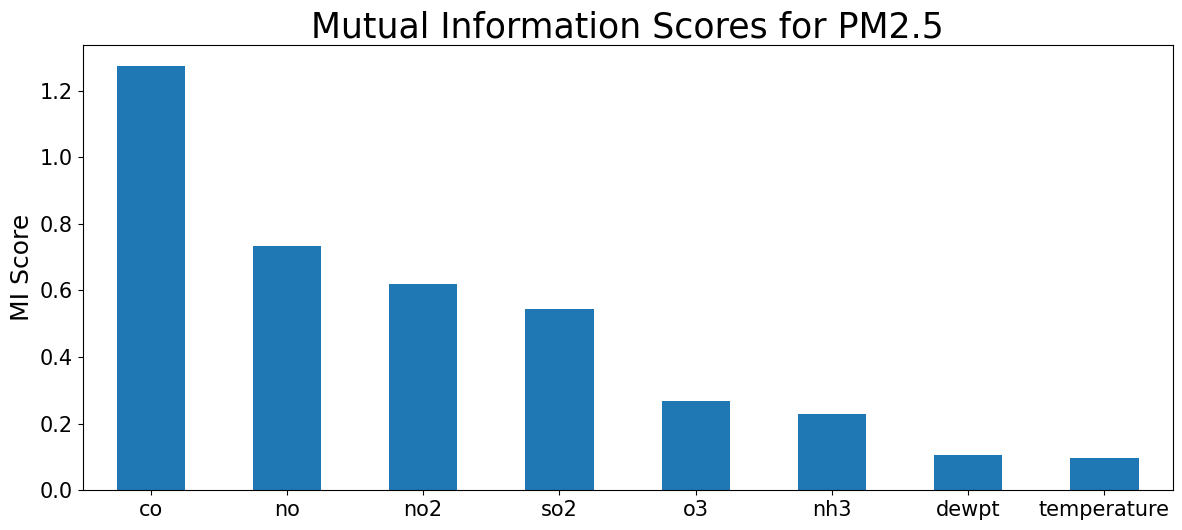

In [18]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import pandas as pd

# Load clean (unwinsorized) training split produced by phase1.py
import numpy as np
df = pd.read_csv(clean_train_path, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Apply train-only winsorization BEFORE feature selection so that MI/mRMR
# scores reflect the same data distribution the models actually receive.
# Bounds are fitted from this same training set — no test data involved.
numeric_cols = df.select_dtypes(include='number').columns
wins_low  = df[numeric_cols].quantile(0.01)
wins_high = df[numeric_cols].quantile(0.99)
df[numeric_cols] = df[numeric_cols].clip(lower=wins_low, upper=wins_high, axis=1)

df.set_index('datetime', inplace=True)

features = ['co', 'no', 'no2', 'o3', 'so2', 'nh3', 'temperature', 'dewpt']

X = df[features]
y_pm25 = df['pm2_5']
y_pm10 = df['pm10']

# Mutual Information for PM2.5
mi_pm25 = mutual_info_regression(X, y_pm25)
mi_scores_pm25 = pd.Series(mi_pm25, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 10))  # big figure

# --- PM2.5 subplot ---
plt.subplot(2, 1, 1)
mi_scores_pm25.plot(kind='bar')
plt.title("Mutual Information Scores for PM2.5", fontsize=25)
plt.ylabel("MI Score", fontsize=18)
plt.xticks(fontsize=15, rotation=0)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()


### mRMR (Minimum Redundancy Maximum Relevance)

In [19]:
! pip install pymrmr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp312-cp312-linux_x86_64.whl size=411149 sha256=1689a3043c96e67c27dfe666b1c10a846c10273165b5eac6c35db9bdcc0a5392
  Stored in directory: /root/.cache/pip/wheels/d8/8b/01/15ccb01b7f3703042aef0458e113d6d3568c22d0a54c2974fb
Successfully built pymrmr


In [21]:
import pymrmr

# pymrmr requires all numerical data and no NaNs
df_mrmr = df[features + ['pm2_5', 'pm10']].dropna()
df_mrmr = df_mrmr.reset_index(drop=True)

# mRMR for PM2.5 (returns top 5 features)
mrmr_pm25 = pymrmr.mRMR(df_mrmr.drop(columns=['pm10']).rename(columns={'pm2_5': 'target'}), 'MIQ', 5)

print("Top mRMR Features for PM2.5:", mrmr_pm25)

Top mRMR Features for PM2.5: ['target', 'o3', 'no', 'no2', 'so2']


# Regime 1: Weekly Walk-forward Refit (Enhanced)

**Features:**
- **3 Models**: NeuralProphet, FBProphet, SARIMAX
- **Targets**: pm2.5
- **Data Split**: 90/10 Train/Test
- **Regressors**: 'no', 'no2', 'co', 'so2'
- **Strategy**: First iteration uses 90% training data, then add observed test weeks
- **Output**: Weekly plots for each model-week combination

In [1]:
! pip install neuralprophet
! pip install prophet
! pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

# Create directory for weekly plots
regime1_weekly_plots_dir = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/regime1_weekly_plots_new"
os.makedirs('/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/regime1_weekly_plots_new', exist_ok=True)

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [3]:
clean_train_path = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_train_clean.csv"
clean_test_path  = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/data/beijing_test_clean.csv"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load CLEAN (unwinsorized) splits produced by phase1.
# Winsorization is handled per walk-forward window below — this is the
# methodologically correct approach for rolling evaluation:
#   - bounds are re-estimated from the expanding training window at every step
#   - the next test week is clipped with those same bounds
#   - no future data ever influences any preprocessing decision
df_train_initial = pd.read_csv(clean_train_path, parse_dates=['datetime'])
df_test          = pd.read_csv(clean_test_path,  parse_dates=['datetime'])
df_train_initial = df_train_initial.sort_values('datetime').reset_index(drop=True)
df_test          = df_test.sort_values('datetime').reset_index(drop=True)

# Walk-forward parameters
print('='*60)
print('REGIME 1: WEEKLY WALK-FORWARD REFIT')
print('='*60)
print(f'\nData Split:')
print(f'  Train rows: {len(df_train_initial)} (90%)')
print(f'  Train days: {len(df_train_initial) / 24:.1f}')
print(f'  Test rows: {len(df_test)} (10%)')
print(f'  Test days: {len(df_test) / 24:.1f}')

# Walk-forward parameters
step_size = 168  # 7 days * 24 hours
forecast_horizon = 168
num_train_weeks = len(df_train_initial) // step_size
print(f'  Number of train weeks: {num_train_weeks}')
num_test_weeks = len(df_test) // step_size
print(f'  Number of test weeks: {num_test_weeks}')

# Regressors
regressors = ['no', 'no2', 'co', 'so2']
print(f'  Regressors: {regressors}')

# Storage
results_regime1 = {}


REGIME 1: WEEKLY WALK-FORWARD REFIT

Data Split:
  Train rows: 35571 (90%)
  Train days: 1482.1
  Test rows: 3952 (10%)
  Test days: 164.7
  Number of train weeks: 211
  Number of test weeks: 23
  Regressors: ['no', 'no2', 'co', 'so2']


## Model 1: NeuralProphet

In [9]:
# NeuralProphet - PM2.5
print('\n' + '='*60)
print('NeuralProphet - PM2.5')
print('='*60)
import time
start_time = time.perf_counter()

all_forecasts = []
all_actuals = []

for week_idx in range(num_test_weeks):
    test_start_idx = week_idx * step_size
    if test_start_idx == 0:
        df_train_current = df_train_initial.copy()
    else:
        df_train_current = pd.concat([df_train_initial, df_test.iloc[:test_start_idx]], ignore_index=True)

    train_days = len(df_train_current) / 24
    print(f'\nWeek {week_idx + 1}/{num_test_weeks}')
    print(f'  Train: {len(df_train_current)} rows ({train_days:.1f} days)')

    # ── Per-window leakage-safe winsorization ────────────────────────────────
    # Fit bounds from the CURRENT expanding training window (all data seen so far).
    # Apply the same bounds to this week's test slice — no future data used.
    numeric_cols_w = df_train_current.select_dtypes(include='number').columns
    wins_low_w  = df_train_current[numeric_cols_w].quantile(0.01)
    wins_high_w = df_train_current[numeric_cols_w].quantile(0.99)
    df_train_current[numeric_cols_w] = df_train_current[numeric_cols_w].clip(
        lower=wins_low_w, upper=wins_high_w, axis=1
    )
    test_week = df_test.iloc[test_start_idx:test_start_idx + step_size].copy()
    test_week[numeric_cols_w] = test_week[numeric_cols_w].clip(
        lower=wins_low_w, upper=wins_high_w, axis=1
    )
    # ─────────────────────────────────────────────────────────────────────────

    # Prepare training data
    train_data = df_train_current[['datetime', 'pm2_5'] + regressors].copy()
    train_data.columns = ['ds', 'y'] + regressors
    train_data = train_data.sort_values("ds").set_index("ds")
    train_data = train_data.asfreq("H")  # forces continuous hourly index
    train_data[['y'] + regressors] = train_data[['y'] + regressors].ffill().bfill()
    train_data = train_data.reset_index()

    # Fit scaler ONLY on current training window
    scaler = StandardScaler()
    scaler.fit(train_data[regressors])

    # Transform training data
    train_data[regressors] = scaler.transform(train_data[regressors])

    # Initialize model with drop_missing=True
    model = NeuralProphet(
        n_lags=168,
        n_forecasts=forecast_horizon,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        epochs=30,
        batch_size=128,
        learning_rate=0.001,
        drop_missing=False,
        impute_missing=True
    )
    for reg in regressors:
        model.add_future_regressor(reg)  # PP: actual future values will be provided

    cols = ['ds','y'] + regressors
    print("After reindex NaNs:\n", train_data[['y'] + regressors].isna().sum())

    model.fit(train_data, freq='H')

    # Perfect Prognosis: pass the actual (scaled) next-week regressor values
    # as regressors_df to make_future_dataframe — this is the required NeuralProphet
    # API for add_future_regressor() (cannot be injected by mutating future_df).
    n_future = min(forecast_horizon, len(test_week))
    future_regs_scaled = scaler.transform(test_week[regressors].values[:n_future])
    # Pad with last known value if final week is shorter than forecast_horizon
    if n_future < forecast_horizon:
        pad = np.repeat(future_regs_scaled[-1:], forecast_horizon - n_future, axis=0)
        future_regs_scaled = np.vstack([future_regs_scaled, pad])
    regressors_df = pd.DataFrame(future_regs_scaled, columns=regressors)

    future_df = model.make_future_dataframe(
        train_data, periods=forecast_horizon,
        n_historic_predictions=True,
        regressors_df=regressors_df
    )

    forecast = model.predict(future_df)

    # Extract forecasts - get the last forecast_horizon predictions
    yhat_cols = [f"yhat{i}" for i in range(1, forecast_horizon + 1)]

    # Forecast origin = last observed timestamp in train_data
    origin_ds = train_data["ds"].max()

    origin_row = forecast.loc[forecast["ds"] == origin_ds, yhat_cols]
    if origin_row.empty:
        print("  Warning: origin row not found in forecast.")
        continue

    week_forecast = origin_row.iloc[0].to_numpy()

    # Get actuals
    test_end_idx = min(test_start_idx + step_size, len(df_test))
    week_actual = test_week['pm2_5'].values[:168]

    # Align lengths
    min_len = min(len(week_actual), len(week_forecast))
    week_actual = week_actual[:min_len]
    week_forecast = week_forecast[:min_len]

    # Remove NaN values from both arrays (keep indices aligned)
    valid_mask = ~(np.isnan(week_forecast) | np.isnan(week_actual))
    week_forecast_clean = week_forecast[valid_mask]
    week_actual_clean = week_actual[valid_mask]

    if len(week_forecast_clean) == 0:
        print(f'  Warning: All forecasts are NaN for this week, skipping')
        continue

    # Weekly plot
    plt.figure(figsize=(12, 5))
    plt.plot(week_actual_clean, label='Actual', color='black', linewidth=2)
    plt.plot(week_forecast_clean, label='Forecast', color='blue', linewidth=2, alpha=0.7)
    plt.title(f'NeuralProphet - PM2.5 - Week {week_idx + 1}', fontweight='bold', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{regime1_weekly_plots_dir}/np_pm25_w{week_idx + 1}.png', dpi=150, bbox_inches='tight')
    plt.close()

    all_forecasts.extend(week_forecast_clean)
    all_actuals.extend(week_actual_clean)
    print(f'  Week MAE: {mean_absolute_error(week_actual_clean, week_forecast_clean):.2f}')
    print(f'  Valid predictions: {len(week_forecast_clean)}/{len(week_forecast)}')

all_forecasts = np.array(all_forecasts)
all_actuals = np.array(all_actuals)
results_regime1['NeuralProphet_pm2.5'] = {
    'forecasts': all_forecasts, 'actuals': all_actuals,
    'mae': mean_absolute_error(all_actuals, all_forecasts),
    'rmse': np.sqrt(mean_squared_error(all_actuals, all_forecasts))
}
print(f"\nOverall MAE: {results_regime1['NeuralProphet_pm2.5']['mae']:.2f}")
print(f"Overall RMSE: {results_regime1['NeuralProphet_pm2.5']['rmse']:.2f}")

end_time = time.perf_counter()

elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"Execution Time: {minutes} min {seconds:.2f} sec")


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.997% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.997% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.



NeuralProphet - PM2.5

Week 1/23
  Train: 35571 rows (1482.1 days)
After reindex NaNs:
 y      0
no     0
no2    0
co     0
so2    0
dtype: int64


Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.997% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.997% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.997% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.997% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.997% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.997% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is

Predicting: 280it [00:00, ?it/s]

...

Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is

Predicting: 310it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


  Week MAE: 28.46
  Valid predictions: 168/168

Overall MAE: 140.55
Overall RMSE: 228.87
Execution Time: 88 min 35.19 sec


## Model 2: FBProphet

In [7]:
# FBProphet - PM2.5
print('\n' + '='*60)
print('FBProphet - PM2.5')
print('='*60)
import time
start_time = time.perf_counter()

all_forecasts = []
all_actuals = []

for week_idx in range(num_test_weeks):
    test_start_idx = week_idx * step_size
    if test_start_idx == 0:
        df_train_current = df_train_initial.copy()
    else:
        df_train_current = pd.concat([df_train_initial, df_test.iloc[:test_start_idx]], ignore_index=True)

    train_days = len(df_train_current) / 24
    print(f'\nWeek {week_idx + 1}/{num_test_weeks}')
    print(f'  Train: {len(df_train_current)} rows ({train_days:.1f} days)')

    # ── Per-window leakage-safe winsorization ────────────────────────────────
    numeric_cols_w = df_train_current.select_dtypes(include='number').columns
    wins_low_w  = df_train_current[numeric_cols_w].quantile(0.01)
    wins_high_w = df_train_current[numeric_cols_w].quantile(0.99)
    df_train_current[numeric_cols_w] = df_train_current[numeric_cols_w].clip(
        lower=wins_low_w, upper=wins_high_w, axis=1
    )
    test_week = df_test.iloc[test_start_idx:test_start_idx + step_size].copy()
    test_week[numeric_cols_w] = test_week[numeric_cols_w].clip(
        lower=wins_low_w, upper=wins_high_w, axis=1
    )
    # ─────────────────────────────────────────────────────────────────────────

    # ── Per-window leakage-safe scaling ───────────────────────────────────
    # Fit StandardScaler on training regressors only (same window as above).
    # Apply the same scaler to the next test week's known regressor values.
    scaler_w = StandardScaler()
    df_train_current[regressors] = scaler_w.fit_transform(df_train_current[regressors])
    test_week[regressors] = scaler_w.transform(test_week[regressors])
    # ─────────────────────────────────────────────────────────────────────────

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    for reg in regressors:
        model.add_regressor(reg)

    train_data = df_train_current[['datetime', 'pm2_5'] + regressors].copy()
    train_data.columns = ['ds', 'y'] + regressors
    model.fit(train_data)

    # Create future dataframe (includes historical + forecast periods)
    future_df = model.make_future_dataframe(periods=forecast_horizon, freq='H')

    test_end_idx = min(test_start_idx + forecast_horizon, len(df_test))
    df_full = pd.concat([df_train_current, test_week], ignore_index=True)

    # Add regressors to future_df (need full length matching future_df)
    for reg in regressors:
        future_df[reg] = df_full[reg].values[:len(future_df)]

    forecast = model.predict(future_df)
    week_forecast = forecast.iloc[-forecast_horizon:]['yhat'].values
    week_actual = test_week['pm2_5'].values[:forecast_horizon]

    plt.figure(figsize=(12, 5))
    plt.plot(week_actual, label='Actual', color='black', linewidth=2)
    plt.plot(week_forecast[:len(week_actual)], label='Forecast', color='green', linewidth=2, alpha=0.7)
    plt.title(f'FBProphet - PM2.5 - Week {week_idx + 1}', fontweight='bold', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{regime1_weekly_plots_dir}/fbp/fbp_pm25_w{week_idx + 1}.png', dpi=150, bbox_inches='tight')
    plt.close()

    all_forecasts.extend(week_forecast[:len(week_actual)])
    all_actuals.extend(week_actual)
    print(f'  Week MAE: {mean_absolute_error(week_actual, week_forecast[:len(week_actual)]):.2f}')

all_forecasts = np.array(all_forecasts)
all_actuals = np.array(all_actuals)
results_regime1['FBProphet_ds0_pm2.5'] = {
    'forecasts': all_forecasts, 'actuals': all_actuals,
    'mae': mean_absolute_error(all_actuals, all_forecasts),
    'rmse': np.sqrt(mean_squared_error(all_actuals, all_forecasts))
}
print(f"\nOverall MAE: {results_regime1['FBProphet_ds0_pm2.5']['mae']:.2f}")
print(f"Overall RMSE: {results_regime1['FBProphet_ds0_pm2.5']['rmse']:.2f}")

end_time = time.perf_counter()

elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"Execution Time: {minutes} min {seconds:.2f} sec")



FBProphet - PM2.5

Week 1/23
  Train: 35571 rows (1482.1 days)
  Week MAE: 18.58

Week 2/23
  Train: 35739 rows (1489.1 days)
  Week MAE: 27.34

Week 3/23
  Train: 35907 rows (1496.1 days)
  Week MAE: 40.42

Week 4/23
  Train: 36075 rows (1503.1 days)
  Week MAE: 25.46

Week 5/23
  Train: 36243 rows (1510.1 days)
  Week MAE: 18.87

Week 6/23
  Train: 36411 rows (1517.1 days)
  Week MAE: 33.67

Week 7/23
  Train: 36579 rows (1524.1 days)
  Week MAE: 23.71

Week 8/23
  Train: 36747 rows (1531.1 days)
  Week MAE: 47.78

Week 9/23
  Train: 36915 rows (1538.1 days)
  Week MAE: 43.33

Week 10/23
  Train: 37083 rows (1545.1 days)
  Week MAE: 42.77

Week 11/23
  Train: 37251 rows (1552.1 days)
  Week MAE: 32.02

Week 12/23
  Train: 37419 rows (1559.1 days)
  Week MAE: 38.86

Week 13/23
  Train: 37587 rows (1566.1 days)
  Week MAE: 37.36

Week 14/23
  Train: 37755 rows (1573.1 days)
  Week MAE: 51.17

Week 15/23
  Train: 37923 rows (1580.1 days)
  Week MAE: 46.01

Week 16/23
  Train: 38091 row

## Model 3: SARIMAX

In [ ]:
print('\n' + '='*60)
print('SARIMAX - PM2.5')
print('='*60)

import time
import gc
import pickle
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

start_time = time.perf_counter()

all_forecasts = []
all_actuals = []
completed_weeks = 0
previous_params = None

# initialize result slot before loop
results_regime1['SARIMAX_pm2.5'] = {
    'forecasts': np.array([]),
    'actuals': np.array([]),
    'mae': None,
    'rmse': None,
    'completed_weeks': 0,
    'status': 'running'
}

# optional checkpoint file
checkpoint_path = f'{regime1_weekly_plots_dir}/sarimax/sarimax_pm25_checkpoint.pkl'

try:
    for week_idx in range(num_test_weeks):
        print(f'\nWeek {week_idx + 1}/{num_test_weeks}', flush=True)

        test_start_idx = week_idx * step_size
        if test_start_idx == 0:
            df_train_current = df_train_initial.copy()
        else:
            df_train_current = pd.concat(
                [df_train_initial, df_test.iloc[:test_start_idx]],
                ignore_index=True
            )

        train_days = len(df_train_current) / 24
        print(f'  Train: {len(df_train_current)} rows ({train_days:.1f} days)', flush=True)

        train_series = df_train_current['pm2_5'].values
        train_exog = df_train_current[regressors].values

        model = SARIMAX(
            train_series,
            exog=train_exog,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        if previous_params is None:
            model_fit = model.fit(
                disp=False,
                method='lbfgs',
                maxiter=50
            )
        else:
            model_fit = model.fit(
                start_params=previous_params,
                disp=False,
                method='lbfgs',
                maxiter=30
            )

        previous_params = np.array(model_fit.params, copy=True)

        test_end_idx = min(test_start_idx + forecast_horizon, len(df_test))
        forecast_exog = df_test.iloc[test_start_idx:test_end_idx][regressors].values
        week_forecast = model_fit.forecast(steps=len(forecast_exog), exog=forecast_exog)
        week_actual = df_test.iloc[test_start_idx:test_end_idx]['pm2_5'].values

        # plot
        plt.figure(figsize=(12, 5))
        plt.plot(week_actual, label='Actual', color='black', linewidth=2)
        plt.plot(week_forecast[:len(week_actual)], label='Forecast', color='red', linewidth=2, alpha=0.7)
        plt.title(f'SARIMAX - PM2.5 - Week {week_idx + 1}', fontweight='bold', fontsize=14)
        plt.xlabel('Hour')
        plt.ylabel('PM2.5')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            f'{regime1_weekly_plots_dir}/sarimax/sarimax_pm25_w{week_idx + 1}.png',
            dpi=150,
            bbox_inches='tight'
        )
        plt.close()

        # store week results
        all_forecasts.extend(week_forecast[:len(week_actual)])
        all_actuals.extend(week_actual)
        completed_weeks += 1

        week_mae = mean_absolute_error(week_actual, week_forecast[:len(week_actual)])
        print(f'  Week MAE: {week_mae:.2f}', flush=True)

        # update cumulative metrics after every iteration
        current_forecasts = np.array(all_forecasts)
        current_actuals = np.array(all_actuals)
        current_mae = mean_absolute_error(current_actuals, current_forecasts)
        current_rmse = np.sqrt(mean_squared_error(current_actuals, current_forecasts))

        results_regime1['SARIMAX_pm2.5'] = {
            'forecasts': current_forecasts.copy(),
            'actuals': current_actuals.copy(),
            'mae': current_mae,
            'rmse': current_rmse,
            'completed_weeks': completed_weeks,
            'status': 'running'
        }

        print(f'  Cumulative MAE after week {week_idx + 1}: {current_mae:.2f}', flush=True)
        print(f'  Cumulative RMSE after week {week_idx + 1}: {current_rmse:.2f}', flush=True)

        # save checkpoint to disk after every week
        with open(checkpoint_path, 'wb') as f:
            pickle.dump(results_regime1['SARIMAX_pm2.5'], f)

        # free memory aggressively
        try:
            model_fit.remove_data()
        except:
            pass

        del model_fit, model, train_series, train_exog, forecast_exog, week_forecast, week_actual, df_train_current
        gc.collect()

    # mark success if loop finishes
    results_regime1['SARIMAX_pm2.5']['status'] = 'completed'

except MemoryError:
    print('\n[ERROR] RAM crashed / MemoryError occurred during SARIMAX execution.', flush=True)
    print(f'Last completed week: {completed_weeks}', flush=True)

    if len(all_actuals) > 0:
        current_forecasts = np.array(all_forecasts)
        current_actuals = np.array(all_actuals)
        current_mae = mean_absolute_error(current_actuals, current_forecasts)
        current_rmse = np.sqrt(mean_squared_error(current_actuals, current_forecasts))

        results_regime1['SARIMAX_pm2.5'] = {
            'forecasts': current_forecasts.copy(),
            'actuals': current_actuals.copy(),
            'mae': current_mae,
            'rmse': current_rmse,
            'completed_weeks': completed_weeks,
            'status': 'memory_error'
        }

        print(f'Partial Overall MAE: {current_mae:.2f}', flush=True)
        print(f'Partial Overall RMSE: {current_rmse:.2f}', flush=True)

        with open(checkpoint_path, 'wb') as f:
            pickle.dump(results_regime1['SARIMAX_pm2.5'], f)

except Exception as e:
    print('\n[ERROR] Execution stopped due to an exception.', flush=True)
    print(f'Exception: {type(e).__name__}: {e}', flush=True)
    print(f'Last completed week: {completed_weeks}', flush=True)

    if len(all_actuals) > 0:
        current_forecasts = np.array(all_forecasts)
        current_actuals = np.array(all_actuals)
        current_mae = mean_absolute_error(current_actuals, current_forecasts)
        current_rmse = np.sqrt(mean_squared_error(current_actuals, current_forecasts))

        results_regime1['SARIMAX_pm2.5'] = {
            'forecasts': current_forecasts.copy(),
            'actuals': current_actuals.copy(),
            'mae': current_mae,
            'rmse': current_rmse,
            'completed_weeks': completed_weeks,
            'status': f'failed: {type(e).__name__}'
        }

        print(f'Partial Overall MAE: {current_mae:.2f}', flush=True)
        print(f'Partial Overall RMSE: {current_rmse:.2f}', flush=True)

        with open(checkpoint_path, 'wb') as f:
            pickle.dump(results_regime1['SARIMAX_pm2.5'], f)

    traceback.print_exc()

finally:
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    minutes = int(elapsed // 60)
    seconds = elapsed % 60

    print('\n' + '-'*60)
    print(f"Completed Weeks: {results_regime1['SARIMAX_pm2.5']['completed_weeks']}")
    print(f"Status: {results_regime1['SARIMAX_pm2.5']['status']}")
    print(f"MAE: {results_regime1['SARIMAX_pm2.5']['mae']}")
    print(f"RMSE: {results_regime1['SARIMAX_pm2.5']['rmse']}")
    print(f"Execution Time: {minutes} min {seconds:.2f} sec")
    print(f"Checkpoint saved at: {checkpoint_path}")


SARIMAX - PM2.5

Week 1/23
  Train: 35571 rows (1482.1 days)
  Week MAE: 9.64
  Cumulative MAE after week 1: 9.64
  Cumulative RMSE after week 1: 13.59

Week 2/23
  Train: 35739 rows (1489.1 days)
  Week MAE: 31.63
  Cumulative MAE after week 2: 20.63
  Cumulative RMSE after week 2: 30.37

Week 3/23
  Train: 35907 rows (1496.1 days)
  Week MAE: 50.40
  Cumulative MAE after week 3: 30.56
  Cumulative RMSE after week 3: 40.98

Week 4/23
  Train: 36075 rows (1503.1 days)
  Week MAE: 11.63
  Cumulative MAE after week 4: 25.82
  Cumulative RMSE after week 4: 36.46

Week 5/23
  Train: 36243 rows (1510.1 days)
  Week MAE: 8.77
  Cumulative MAE after week 5: 22.41
  Cumulative RMSE after week 5: 33.05

Week 6/23
  Train: 36411 rows (1517.1 days)
  Week MAE: 33.21
  Cumulative MAE after week 6: 24.21
  Cumulative RMSE after week 6: 35.94

Week 7/23
  Train: 36579 rows (1524.1 days)
  Week MAE: 10.17
  Cumulative MAE after week 7: 22.21
  Cumulative RMSE after week 7: 33.92

Week 8/23
  Train: 

## Results Comparison

In [ ]:
# Comparison tables
print('\n' + '='*60)
print('RESULTS COMPARISON')
print('='*60)

pm25_comp = pd.DataFrame({
    'Model': ['NeuralProphet', 'FBProphet', 'SARIMAX'],
    'MAE': [results_regime1['NeuralProphet_pm2.5']['mae'],
           results_regime1['FBProphet_pm2.5']['mae'],
           results_regime1['SARIMAX_pm2.5']['mae']],
    'RMSE': [results_regime1['NeuralProphet_pm2.5']['rmse'],
            results_regime1['FBProphet_pm2.5']['rmse'],
            results_regime1['SARIMAX_pm2.5']['rmse']]
}).sort_values('MAE')

pm10_comp = pd.DataFrame({
    'Model': ['NeuralProphet', 'FBProphet', 'SARIMAX'],
    'MAE': [results_regime1['NeuralProphet_pm10']['mae'],
           results_regime1['FBProphet_pm10']['mae'],
           results_regime1['SARIMAX_pm10']['mae']],
    'RMSE': [results_regime1['NeuralProphet_pm10']['rmse'],
            results_regime1['FBProphet_pm10']['rmse'],
            results_regime1['SARIMAX_pm10']['rmse']]
}).sort_values('MAE')

print('\n--- PM2.5 Results ---')
print(pm25_comp.to_string(index=False))
print('\n--- PM10 Results ---')
print(pm10_comp.to_string(index=False))

# Save
pm25_comp.to_csv('./regime1_pm25_comparison.csv', index=False)
pm10_comp.to_csv('./regime1_pm10_comparison.csv', index=False)

In [ ]:
# Overall visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Regime 1: Weekly Walk-forward Refit (Enhanced)', fontsize=16, fontweight='bold')

models_pm25 = ['NeuralProphet_pm2.5', 'FBProphet_pm2.5', 'SARIMAX_pm2.5']
models_pm10 = ['NeuralProphet_pm10', 'FBProphet_pm10', 'SARIMAX_pm10']
colors = ['blue', 'green', 'red']

for idx, (model_key, color) in enumerate(zip(models_pm25, colors)):
    ax = axes[0, idx]
    result = results_regime1[model_key]
    ax.plot(result['actuals'], label='Actual', alpha=0.7, color='black', linewidth=1)
    ax.plot(result['forecasts'], label='Forecast', alpha=0.7, color=color, linewidth=1)
    ax.set_title(f"{model_key.replace('_', ' ').upper()}\nMAE: {result['mae']:.2f}, RMSE: {result['rmse']:.2f}", fontweight='bold')
    ax.set_ylabel('PM2.5')
    ax.legend()
    ax.grid(True, alpha=0.3)

for idx, (model_key, color) in enumerate(zip(models_pm10, colors)):
    ax = axes[1, idx]
    result = results_regime1[model_key]
    ax.plot(result['actuals'], label='Actual', alpha=0.7, color='black', linewidth=1)
    ax.plot(result['forecasts'], label='Forecast', alpha=0.7, color=color, linewidth=1)
    ax.set_title(f"{model_key.replace('_', ' ').upper()}\nMAE: {result['mae']:.2f}, RMSE: {result['rmse']:.2f}", fontweight='bold')
    ax.set_xlabel('Hour')
    ax.set_ylabel('PM10')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./regime1_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nSaved: ./regime1_overall.png')
print('Weekly plots saved in: ./regime1_weekly_plots/')

# Regime 2: Frozen Model + Online Residual Correction

**Strategy:**
- Train each base model **once** on initial 90% data (frozen model)
- Generate weekly forecasts using the frozen model
- Apply **EWMA (Exponentially Weighted Moving Average)** bias correction based on recent residuals
- Corrected forecast: `ŷ_final = ŷ_base + b_t`

**EWMA Bias Update:**
- `b_t = α × e_t + (1-α) × b_{t-1}`
- Where `e_t = actual - predicted` (residual)
- `α = 0.3` (weight for recent errors)

**Benefits:**
- No expensive retraining
- Adaptive to recent trends via residual correction
- Constant memory footprint


In [ ]:
! pip install neuralprophet
! pip install prophet
! pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.7 MB/s eta 0:00:00


In [11]:
# Regime 2 Setup
import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

# Create directory for weekly plots
regime2_weekly_plots_dir = "/content/drive/MyDrive/Moazzam Research Work/Project Weather Forecasting /New Pipeline - Jan 2026/regime2_weekly_plots_new"
os.makedirs(regime2_weekly_plots_dir, exist_ok=True)

# Load CLEAN (unwinsorized) splits produced by phase1.py.
# Regime 2 fits winsorization bounds ONCE on the initial training set
# (frozen alongside the model) and applies those same bounds to every
# test-week slice — consistent with the frozen-model philosophy.
df_train_initial = pd.read_csv(clean_train_path, parse_dates=['datetime'])
df_test          = pd.read_csv(clean_test_path,  parse_dates=['datetime'])
df_train_initial = df_train_initial.sort_values('datetime').reset_index(drop=True)
df_test          = df_test.sort_values('datetime').reset_index(drop=True)

# Walk-forward / evaluation parameters (must match regime1.py)
step_size        = 168          # 7 days × 24 hours
forecast_horizon = 168
num_test_weeks   = len(df_test) // step_size
regressors       = ['no', 'no2', 'co', 'so2']

print(f'Test weeks: {num_test_weeks}  |  Regressors: {regressors}')


print('='*60)
print('REGIME 2: FROZEN MODEL + EWMA RESIDUAL CORRECTION')
print('='*60)

# EWMA parameter
alpha = 0.3  # Weight for recent residuals

# Storage for Regime 2 results
results_regime2 = {}


Test weeks: 23  |  Regressors: ['no', 'no2', 'co', 'so2']
REGIME 2: FROZEN MODEL + EWMA RESIDUAL CORRECTION


## Model 1: NeuralProphet with EWMA


In [12]:
# NeuralProphet - PM2.5 (Frozen + EWMA)
print('\n' + '='*60)
print('NeuralProphet - PM2.5 (Frozen + EWMA)')
print('='*60)
import time
start_time = time.perf_counter()

# ── Frozen winsorization bounds (computed once from initial train) ─────────
# These bounds are frozen alongside the model: the same clip is applied
# to every test-week slice throughout the evaluation phase.
numeric_cols_r2 = df_train_initial.select_dtypes(include='number').columns
wins_low_r2  = df_train_initial[numeric_cols_r2].quantile(0.01)
wins_high_r2 = df_train_initial[numeric_cols_r2].quantile(0.99)

df_train_np = df_train_initial.copy()
df_train_np[numeric_cols_r2] = df_train_np[numeric_cols_r2].clip(
    lower=wins_low_r2, upper=wins_high_r2, axis=1
)
print(f"Frozen winsorization bounds fitted on {len(df_train_np)} training rows.")
# ─────────────────────────────────────────────────────────────────────────

# Prepare training data
train_data = df_train_np[['datetime', 'pm2_5'] + regressors].copy()
train_data.columns = ['ds', 'y'] + regressors
train_data = train_data.sort_values("ds").set_index("ds")
train_data = train_data.asfreq("H")  # forces continuous hourly index
train_data[['y'] + regressors] = train_data[['y'] + regressors].ffill().bfill()
train_data = train_data.reset_index()

scaler = StandardScaler()
train_data[regressors] = scaler.fit_transform(train_data[regressors])

print(f'\nTraining frozen model on {len(train_data)} rows ({len(train_data)/24:.1f} days)')

model_frozen = NeuralProphet(
    n_lags=168, n_forecasts=168,  # Forecast 1 week ahead
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True,
    epochs=30, batch_size=128, learning_rate=0.001, drop_missing=False, impute_missing=True
)
for reg in regressors:
    model_frozen.add_future_regressor(reg)  # PP: actual future values will be provided

model_frozen.fit(train_data, freq='H')
print('Frozen model training complete!')

# Weekly forecasting with EWMA correction
# Use ACTUAL observed data as context, but never retrain the model
all_forecasts_base = []
all_forecasts_corrected = []
all_actuals = []
bias = 0.0

for week_idx in range(num_test_weeks):
    test_start_idx = week_idx * step_size
    test_end_idx = min(test_start_idx + step_size, len(df_test))

    print(f'\nWeek {week_idx + 1}/{num_test_weeks}')

    # Apply frozen bounds to this week's test slice
    test_week = df_test.iloc[test_start_idx:test_end_idx].copy()
    test_week[numeric_cols_r2] = test_week[numeric_cols_r2].clip(
        lower=wins_low_r2, upper=wins_high_r2, axis=1
    )

    # Create context data: training + all observed test data up to this week
    if test_start_idx == 0:
        context_data = train_data.copy()
    else:
        observed_test = df_test.iloc[:test_start_idx].copy()
        observed_test[numeric_cols_r2] = observed_test[numeric_cols_r2].clip(
            lower=wins_low_r2, upper=wins_high_r2, axis=1
        )
        observed_test = observed_test[['datetime', 'pm2_5'] + regressors].copy()
        observed_test.columns = ['ds', 'y'] + regressors
        observed_test = observed_test.sort_values("ds").set_index("ds").asfreq("H")
        observed_test[['y'] + regressors] = observed_test[['y'] + regressors].ffill().bfill()
        observed_test = observed_test.reset_index()

        # Scale ONLY observed_test (train_data is already scaled)
        observed_test[regressors] = scaler.transform(observed_test[regressors])

        # Concatenate scaled train + scaled observed_test
        context_data = pd.concat([train_data, observed_test], ignore_index=True)

    # Generate forecast for this week using frozen model (no retraining)
    try:
        H = 168
        yhat_cols = [f"yhat{i}" for i in range(1, H + 1)]

        # Perfect Prognosis: pass the actual (scaled) next-week regressor values
        # as regressors_df — required NeuralProphet API for add_future_regressor().
        n_future = min(H, len(test_week))
        future_regs_scaled = scaler.transform(test_week[regressors].values[:n_future])
        if n_future < H:
            pad = np.repeat(future_regs_scaled[-1:], H - n_future, axis=0)
            future_regs_scaled = np.vstack([future_regs_scaled, pad])
        regressors_df = pd.DataFrame(future_regs_scaled, columns=regressors)

        future_df = model_frozen.make_future_dataframe(
            context_data, periods=H,
            n_historic_predictions=True,
            regressors_df=regressors_df
        )

        forecast = model_frozen.predict(future_df)

        # Forecast origin is last observed timestamp in context_data
        origin_ds = context_data["ds"].max()

        origin_row = forecast.loc[forecast["ds"] == origin_ds, yhat_cols]
        if origin_row.empty:
            print("  Warning: origin row not found in forecast.")
            continue

        week_forecast_base = origin_row.iloc[0].to_numpy()

    except Exception as e:
        print(f'  Error generating forecast: {e}')
        continue

    # Get actuals from the pre-winsorized test slice
    week_actual = test_week['pm2_5'].values

    # Align lengths
    min_len = min(len(week_actual), len(week_forecast_base))
    week_forecast_base = week_forecast_base[:min_len]
    week_actual = week_actual[:min_len]

    # Filter NaN
    valid_mask = ~(np.isnan(week_forecast_base) | np.isnan(week_actual))
    week_forecast_base_clean = week_forecast_base[valid_mask]
    week_actual_clean = week_actual[valid_mask]

    if len(week_forecast_base_clean) == 0:
        print(f'  Warning: All forecasts are NaN, skipping')
        continue

    # Apply EWMA bias correction
    week_forecast_corrected = week_forecast_base_clean + bias

    # Compute residuals and update bias
    residuals = week_actual_clean - week_forecast_base_clean
    mean_residual = np.mean(residuals)
    bias = alpha * mean_residual + (1 - alpha) * bias

    # Weekly plot
    plt.figure(figsize=(14, 5))
    plt.plot(week_actual_clean, label='Actual', color='black', linewidth=2)
    plt.plot(week_forecast_base_clean, label='Base Forecast', color='lightblue', linewidth=2, alpha=0.7, linestyle='--')
    plt.plot(week_forecast_corrected, label='Corrected (EWMA)', color='blue', linewidth=2, alpha=0.9)
    plt.title(f'NeuralProphet - PM2.5 - Week {week_idx + 1} (Bias={bias:.2f})', fontweight='bold', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{regime2_weekly_plots_dir}/np/np_pm25_w{week_idx + 1}.png', dpi=150, bbox_inches='tight')
    plt.close()

    all_forecasts_base.extend(week_forecast_base_clean)
    all_forecasts_corrected.extend(week_forecast_corrected)
    all_actuals.extend(week_actual_clean)

    mae_base = mean_absolute_error(week_actual_clean, week_forecast_base_clean)
    mae_corrected = mean_absolute_error(week_actual_clean, week_forecast_corrected)
    print(f'  Base MAE: {mae_base:.2f} | Corrected MAE: {mae_corrected:.2f} | Improvement: {mae_base - mae_corrected:.2f}')

# Overall metrics
all_forecasts_base = np.array(all_forecasts_base)
all_forecasts_corrected = np.array(all_forecasts_corrected)
all_actuals = np.array(all_actuals)

results_regime2['NeuralProphet_pm2.5'] = {
    'forecasts': all_forecasts_corrected,
    'actuals': all_actuals,
    'mae': mean_absolute_error(all_actuals, all_forecasts_corrected),
    'rmse': np.sqrt(mean_squared_error(all_actuals, all_forecasts_corrected)),
    'mae_base': mean_absolute_error(all_actuals, all_forecasts_base),
    'rmse_base': np.sqrt(mean_squared_error(all_actuals, all_forecasts_base))
}

print(f"\nOverall Base MAE: {results_regime2['NeuralProphet_pm2.5']['mae_base']:.2f}")
print(f"Overall Corrected MAE: {results_regime2['NeuralProphet_pm2.5']['mae']:.2f}")
print(f"Improvement in MAE: {results_regime2['NeuralProphet_pm2.5']['mae_base'] - results_regime2['NeuralProphet_pm2.5']['mae']:.2f}")
print(f"Overall Base RMSE: {results_regime2['NeuralProphet_pm2.5']['rmse_base']:.2f}")
print(f"Overall Corrected RMSE: {results_regime2['NeuralProphet_pm2.5']['rmse']:.2f}")

end_time = time.perf_counter()

elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"Execution Time: {minutes} min {seconds:.2f} sec")


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.997% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.997% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H



NeuralProphet - PM2.5 (Frozen + EWMA)
Frozen winsorization bounds fitted on 35571 training rows.

Training frozen model on 36075 rows (1503.1 days)


INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.


Training: 0it [00:00, ?it/s]

Frozen model training complete!

Week 1/23


...

  Base MAE: 34.93 | Corrected MAE: 32.16 | Improvement: 2.77

Week 23/23


INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency h corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is

Predicting: 280it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


  Base MAE: 70.05 | Corrected MAE: 59.51 | Improvement: 10.54

Overall Base MAE: 145.75
Overall Corrected MAE: 162.14
Improvement in MAE: -16.39
Overall Base RMSE: 239.95
Overall Corrected RMSE: 247.21
Execution Time: 7 min 30.68 sec


## Model 2: FBProphet with EWMA


In [13]:

# FBProphet - PM2.5 (Frozen + EWMA)
print('\n' + '='*60)
print('FBProphet - PM2.5 (Frozen + EWMA)')
print('='*60)
import time
start_time = time.perf_counter()

# ── Frozen winsorization bounds (computed once from initial train) ─────────
numeric_cols_r2 = df_train_initial.select_dtypes(include='number').columns
wins_low_r2  = df_train_initial[numeric_cols_r2].quantile(0.01)
wins_high_r2 = df_train_initial[numeric_cols_r2].quantile(0.99)

df_train_fbp = df_train_initial.copy()
df_train_fbp[numeric_cols_r2] = df_train_fbp[numeric_cols_r2].clip(
    lower=wins_low_r2, upper=wins_high_r2, axis=1
)
print(f"Frozen winsorization bounds fitted on {len(df_train_fbp)} training rows.")
# ─────────────────────────────────────────────────────────────────────────

# ── Frozen leakage-safe scaling ───────────────────────────────────────
# Fit scaler once on initial training regressors; frozen alongside the model.
scaler_fbp = StandardScaler()
df_train_fbp[regressors] = scaler_fbp.fit_transform(df_train_fbp[regressors])
# ─────────────────────────────────────────────────────────────────────────

# Train frozen model
train_data = df_train_fbp[['datetime', 'pm2_5'] + regressors].copy()
train_data.columns = ['ds', 'y'] + regressors

print(f'\nTraining frozen model on {len(train_data)} rows ({len(train_data)/24:.1f} days)')

model_frozen = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True,
                       )
for reg in regressors:
    model_frozen.add_regressor(reg)

model_frozen.fit(train_data)
print('Frozen model training complete!')

# Weekly forecasting with EWMA
all_forecasts_base = []
all_forecasts_corrected = []
all_actuals = []
bias = 0.0

for week_idx in range(num_test_weeks):
    test_start_idx = week_idx * step_size
    test_end_idx = min(test_start_idx + step_size, len(df_test))

    print(f'\nWeek {week_idx + 1}/{num_test_weeks}')

    # Apply frozen bounds and frozen scaler to this week's test slice
    test_week = df_test.iloc[test_start_idx:test_end_idx].copy()
    test_week[numeric_cols_r2] = test_week[numeric_cols_r2].clip(
        lower=wins_low_r2, upper=wins_high_r2, axis=1
    )
    test_week[regressors] = scaler_fbp.transform(test_week[regressors])

    test_week_df = test_week[['datetime'] + regressors].rename(columns={'datetime': 'ds'})
    future_df = test_week_df

    forecast = model_frozen.predict(future_df)
    week_forecast_base = forecast.iloc[-forecast_horizon:]['yhat'].values

    week_actual = test_week['pm2_5'].values

    min_len = min(len(week_actual), len(week_forecast_base))
    week_actual = week_actual[:min_len]
    week_forecast_base = week_forecast_base[:min_len]

    # Apply EWMA correction
    week_forecast_corrected = week_forecast_base + bias
    residuals = week_actual - week_forecast_base
    mean_residual = np.mean(residuals)
    bias = alpha * mean_residual + (1 - alpha) * bias

    plt.figure(figsize=(14, 5))
    plt.plot(week_actual, label='Actual', color='black', linewidth=2)
    plt.plot(week_forecast_base, label='Base Forecast', color='lightgreen', linewidth=2, alpha=0.7, linestyle='--')
    plt.plot(week_forecast_corrected, label='Corrected (EWMA)', color='green', linewidth=2, alpha=0.9)
    plt.title(f'FBProphet - PM2.5 - Week {week_idx + 1} (Bias={bias:.2f})', fontweight='bold', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{regime2_weekly_plots_dir}/fbp/fbp_pm25_w{week_idx + 1}.png', dpi=150, bbox_inches='tight')
    plt.close()

    all_forecasts_base.extend(week_forecast_base)
    all_forecasts_corrected.extend(week_forecast_corrected)
    all_actuals.extend(week_actual)

    mae_base = mean_absolute_error(week_actual, week_forecast_base)
    mae_corrected = mean_absolute_error(week_actual, week_forecast_corrected)
    print(f'  Base MAE: {mae_base:.2f} | Corrected MAE: {mae_corrected:.2f} | Improvement: {mae_base - mae_corrected:.2f}')

all_forecasts_base = np.array(all_forecasts_base)
all_forecasts_corrected = np.array(all_forecasts_corrected)
all_actuals = np.array(all_actuals)

results_regime2['FBProphet_pm2.5'] = {
    'forecasts': all_forecasts_corrected,
    'actuals': all_actuals,
    'mae': mean_absolute_error(all_actuals, all_forecasts_corrected),
    'rmse': np.sqrt(mean_squared_error(all_actuals, all_forecasts_corrected)),
    'mae_base': mean_absolute_error(all_actuals, all_forecasts_base),
    'rmse_base': np.sqrt(mean_squared_error(all_actuals, all_forecasts_base))
}

print(f"\nOverall Base MAE: {results_regime2['FBProphet_pm2.5']['mae_base']:.2f}")
print(f"Overall Corrected MAE: {results_regime2['FBProphet_pm2.5']['mae']:.2f}")
print(f"Improvement in MAE: {results_regime2['FBProphet_pm2.5']['mae_base'] - results_regime2['FBProphet_pm2.5']['mae']:.2f}")
print(f"Overall Base RMSE: {results_regime2['FBProphet_pm2.5']['rmse_base']:.2f}")
print(f"Overall Corrected RMSE: {results_regime2['FBProphet_pm2.5']['rmse']:.2f}")

end_time = time.perf_counter()

elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"Execution Time: {minutes} min {seconds:.2f} sec")



FBProphet - PM2.5 (Frozen + EWMA)
Frozen winsorization bounds fitted on 35571 training rows.

Training frozen model on 35571 rows (1482.1 days)
Frozen model training complete!

Week 1/23
  Base MAE: 18.58 | Corrected MAE: 18.58 | Improvement: 0.00

Week 2/23
  Base MAE: 27.31 | Corrected MAE: 27.74 | Improvement: -0.43

Week 3/23
  Base MAE: 40.61 | Corrected MAE: 40.52 | Improvement: 0.08

Week 4/23
  Base MAE: 25.86 | Corrected MAE: 26.01 | Improvement: -0.14

Week 5/23
  Base MAE: 18.41 | Corrected MAE: 20.00 | Improvement: -1.59

Week 6/23
  Base MAE: 34.17 | Corrected MAE: 34.28 | Improvement: -0.12

Week 7/23
  Base MAE: 25.06 | Corrected MAE: 24.30 | Improvement: 0.75

Week 8/23
  Base MAE: 48.07 | Corrected MAE: 48.06 | Improvement: 0.01

Week 9/23
  Base MAE: 48.96 | Corrected MAE: 47.90 | Improvement: 1.06

Week 10/23
  Base MAE: 46.86 | Corrected MAE: 43.66 | Improvement: 3.20

Week 11/23
  Base MAE: 39.43 | Corrected MAE: 32.03 | Improvement: 7.40

Week 12/23
  Base MAE: 3

## Model 3: SARIMAX with EWMA


In [14]:
# SARIMAX - PM2.5 (Frozen + EWMA)
print('\n' + '='*60)
print('SARIMAX - PM2.5 (Frozen + EWMA)')
print('='*60)
import time
start_time = time.perf_counter()

# ── Frozen winsorization bounds (computed once from initial train) ─────────
numeric_cols_r2 = df_train_initial.select_dtypes(include='number').columns
wins_low_r2  = df_train_initial[numeric_cols_r2].quantile(0.01)
wins_high_r2 = df_train_initial[numeric_cols_r2].quantile(0.99)

df_train_sx = df_train_initial.copy()
df_train_sx[numeric_cols_r2] = df_train_sx[numeric_cols_r2].clip(
    lower=wins_low_r2, upper=wins_high_r2, axis=1
)
print(f"Frozen winsorization bounds fitted on {len(df_train_sx)} training rows.")
# ─────────────────────────────────────────────────────────────────────────

# ── Frozen leakage-safe scaling ───────────────────────────────────────
scaler_sx = StandardScaler()
df_train_sx[regressors] = scaler_sx.fit_transform(df_train_sx[regressors])
# ─────────────────────────────────────────────────────────────────────────

# Train frozen model
print(f'\nTraining frozen model on {len(df_train_sx)} rows ({len(df_train_sx)/24:.1f} days)')

train_series = df_train_sx['pm2_5'].values
train_exog = df_train_sx[regressors].values

model_frozen = SARIMAX(train_series, exog=train_exog, order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 24),
                       enforce_stationarity=False, enforce_invertibility=False)
model_fit = model_frozen.fit(disp=False)
print('Frozen model training complete!')

# Weekly forecasting with EWMA
all_forecasts_base = []
all_forecasts_corrected = []
all_actuals = []
bias = 0.0

for week_idx in range(num_test_weeks):
    test_start_idx = week_idx * step_size
    test_end_idx = min(test_start_idx + step_size, len(df_test))

    print(f'\nWeek {week_idx + 1}/{num_test_weeks}')

    # Apply frozen bounds and frozen scaler to this week's test slice
    test_week = df_test.iloc[test_start_idx:test_end_idx].copy()
    test_week[numeric_cols_r2] = test_week[numeric_cols_r2].clip(
        lower=wins_low_r2, upper=wins_high_r2, axis=1
    )
    test_week[regressors] = scaler_sx.transform(test_week[regressors])

    # Generate base forecast using scaled test exog
    forecast_exog = test_week[regressors].values
    week_forecast_base = model_fit.forecast(steps=len(forecast_exog), exog=forecast_exog)

    week_actual = test_week['pm2_5'].values

    # Apply EWMA correction
    week_forecast_corrected = week_forecast_base + bias
    residuals = week_actual - week_forecast_base
    mean_residual = np.mean(residuals)
    bias = alpha * mean_residual + (1 - alpha) * bias

    plt.figure(figsize=(14, 5))
    plt.plot(week_actual, label='Actual', color='black', linewidth=2)
    plt.plot(week_forecast_base, label='Base Forecast', color='lightcoral', linewidth=2, alpha=0.7, linestyle='--')
    plt.plot(week_forecast_corrected, label='Corrected (EWMA)', color='red', linewidth=2, alpha=0.9)
    plt.title(f'SARIMAX - PM2.5 - Week {week_idx + 1} (Bias={bias:.2f})', fontweight='bold', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{regime2_weekly_plots_dir}/sarimax/sarimax_pm25_w{week_idx + 1}.png', dpi=150, bbox_inches='tight')
    plt.close()

    all_forecasts_base.extend(week_forecast_base)
    all_forecasts_corrected.extend(week_forecast_corrected)
    all_actuals.extend(week_actual)

    mae_base = mean_absolute_error(week_actual, week_forecast_base)
    mae_corrected = mean_absolute_error(week_actual, week_forecast_corrected)
    print(f'  Base MAE: {mae_base:.2f} | Corrected MAE: {mae_corrected:.2f} | Improvement: {mae_base - mae_corrected:.2f}')

all_forecasts_base = np.array(all_forecasts_base)
all_forecasts_corrected = np.array(all_forecasts_corrected)
all_actuals = np.array(all_actuals)

results_regime2['SARIMAX_pm2.5'] = {
    'forecasts': all_forecasts_corrected,
    'actuals': all_actuals,
    'mae': mean_absolute_error(all_actuals, all_forecasts_corrected),
    'rmse': np.sqrt(mean_squared_error(all_actuals, all_forecasts_corrected)),
    'mae_base': mean_absolute_error(all_actuals, all_forecasts_base),
    'rmse_base': np.sqrt(mean_squared_error(all_actuals, all_forecasts_base))
}

print(f"\nOverall Base MAE: {results_regime2['SARIMAX_pm2.5']['mae_base']:.2f}")
print(f"Overall Corrected MAE: {results_regime2['SARIMAX_pm2.5']['mae']:.2f}")
print(f"Improvement in MAE: {results_regime2['SARIMAX_pm2.5']['mae_base'] - results_regime2['SARIMAX_pm2.5']['mae']:.2f}")
print(f"Overall Base RMSE: {results_regime2['SARIMAX_pm2.5']['rmse_base']:.2f}")
print(f"Overall Corrected RMSE: {results_regime2['SARIMAX_pm2.5']['rmse']:.2f}")

end_time = time.perf_counter()

elapsed = end_time - start_time
minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"Execution Time: {minutes} min {seconds:.2f} sec")



SARIMAX - PM2.5 (Frozen + EWMA)
Frozen winsorization bounds fitted on 35571 training rows.

Training frozen model on 35571 rows (1482.1 days)
Frozen model training complete!

Week 1/23
  Base MAE: 10.81 | Corrected MAE: 10.81 | Improvement: 0.00

Week 2/23
  Base MAE: 32.52 | Corrected MAE: 31.15 | Improvement: 1.37

Week 3/23
  Base MAE: 37.71 | Corrected MAE: 30.46 | Improvement: 7.26

Week 4/23
  Base MAE: 12.15 | Corrected MAE: 19.11 | Improvement: -6.97

Week 5/23
  Base MAE: 12.23 | Corrected MAE: 9.96 | Improvement: 2.27

Week 6/23
  Base MAE: 35.59 | Corrected MAE: 29.96 | Improvement: 5.63

Week 7/23
  Base MAE: 10.99 | Corrected MAE: 17.13 | Improvement: -6.14

Week 8/23
  Base MAE: 68.14 | Corrected MAE: 62.04 | Improvement: 6.11

Week 9/23
  Base MAE: 64.40 | Corrected MAE: 56.31 | Improvement: 8.09

Week 10/23
  Base MAE: 19.16 | Corrected MAE: 36.50 | Improvement: -17.33

Week 11/23
  Base MAE: 23.52 | Corrected MAE: 32.74 | Improvement: -9.21

Week 12/23
  Base MAE: 28.

## Results Comparison



REGIME 2 RESULTS COMPARISON

--- PM2.5 Results ---
        Model  MAE (Base)  MAE (EWMA)  RMSE (Base)  RMSE (EWMA)  MAE Improvement
      SARIMAX   47.144285   32.504433    65.451007    46.851355        14.639852
    FBProphet   45.605138   37.672171    60.386491    50.077324         7.932966
NeuralProphet  145.753194  162.142272   239.954926   247.206912       -16.389078


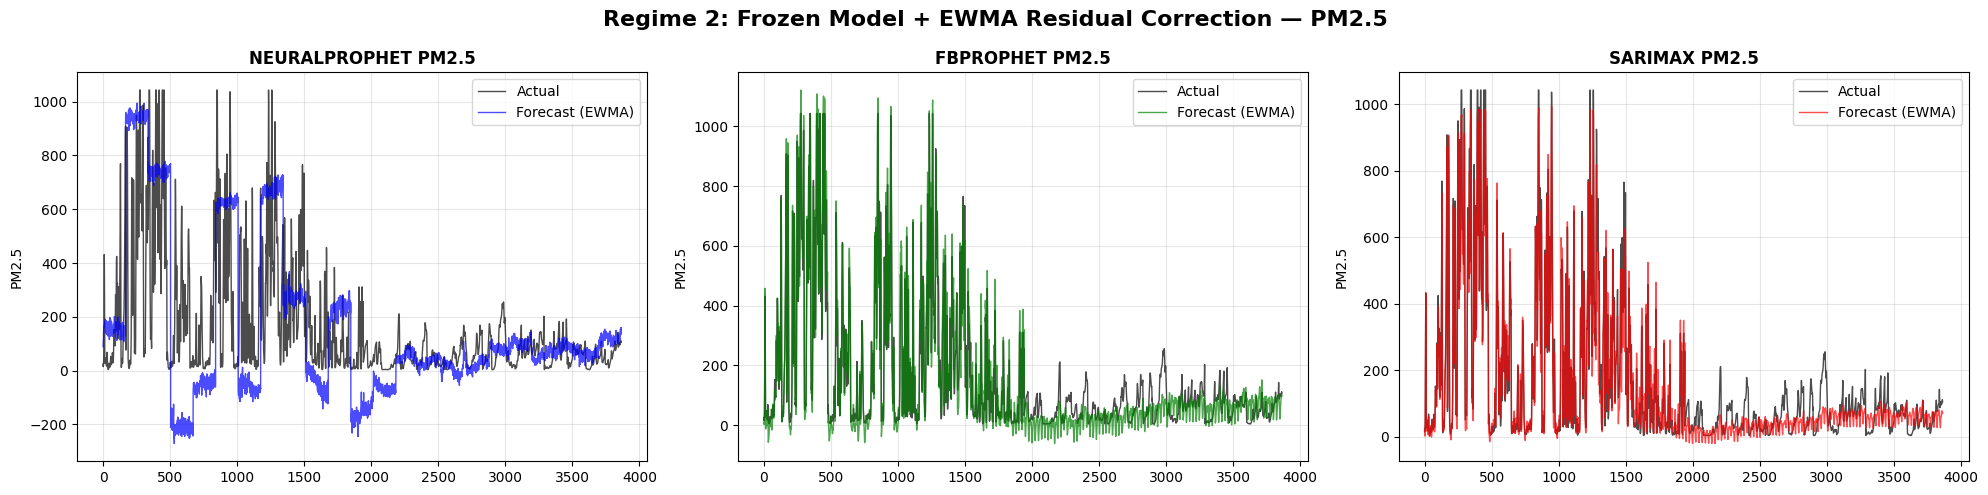

In [15]:
# Regime 2 Results Comparison
print('\n' + '='*60)
print('REGIME 2 RESULTS COMPARISON')
print('='*60)

# PM2.5 Comparison
pm25_comp = pd.DataFrame({
    'Model': ['NeuralProphet', 'FBProphet', 'SARIMAX'],
    'MAE (Base)': [
        results_regime2['NeuralProphet_pm2.5']['mae_base'],
        results_regime2['FBProphet_pm2.5']['mae_base'],
        results_regime2['SARIMAX_pm2.5']['mae_base']
    ],
    'MAE (EWMA)': [
        results_regime2['NeuralProphet_pm2.5']['mae'],
        results_regime2['FBProphet_pm2.5']['mae'],
        results_regime2['SARIMAX_pm2.5']['mae']
    ],
    'RMSE (Base)': [
        results_regime2['NeuralProphet_pm2.5']['rmse_base'],
        results_regime2['FBProphet_pm2.5']['rmse_base'],
        results_regime2['SARIMAX_pm2.5']['rmse_base']
    ],
    'RMSE (EWMA)': [
        results_regime2['NeuralProphet_pm2.5']['rmse'],
        results_regime2['FBProphet_pm2.5']['rmse'],
        results_regime2['SARIMAX_pm2.5']['rmse']
    ]
})
pm25_comp['MAE Improvement'] = pm25_comp['MAE (Base)'] - pm25_comp['MAE (EWMA)']
pm25_comp = pm25_comp.sort_values('MAE (EWMA)')

print('\n--- PM2.5 Results ---')
print(pm25_comp.to_string(index=False))
# print('\n--- PM10 Results ---')
# print(pm10_comp.to_string(index=False))


# Regime 2 Overall Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Regime 2: Frozen Model + EWMA Residual Correction — PM2.5', fontsize=16, fontweight='bold')

models_pm25 = ['NeuralProphet_pm2.5', 'FBProphet_pm2.5', 'SARIMAX_pm2.5']
colors = ['blue', 'green', 'red']

for idx, (model_key, color) in enumerate(zip(models_pm25, colors)):
    ax = axes[idx]
    result = results_regime2[model_key]
    ax.plot(result['actuals'], label='Actual', alpha=0.7, color='black', linewidth=1)
    ax.plot(result['forecasts'], label='Forecast (EWMA)', alpha=0.7, color=color, linewidth=1)
    ax.set_title(f"{model_key.replace('_', ' ').upper()}", fontweight='bold')
    ax.set_ylabel('PM2.5')
    ax.legend()
    ax.grid(True, alpha=0.3)


plt.tight_layout()
#plt.savefig('./regime2_overall.png', dpi=300, bbox_inches='tight')
plt.show()

#print('\nSaved: ./regime2_overall.png')
#print('Weekly plots saved in: ./regime2_weekly_plots/')